# Model Comparison and Analysis
Comparing XGBoost vs Random Forest performance on retail sales forecasting

## Importing libraries for loading, generating, and comparing models

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
import sys
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuring graph properties

In [37]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Adding project root to path

In [38]:
project_root = Path.cwd().parent  # Going up one level from notebooks folder
sys.path.insert(0, str(project_root))

# Loading models, data, and feature columns

In [39]:
# Loading trained models
xgb_model = joblib.load('../trained_models/xgboost_model.pkl')
rf_model = joblib.load('../trained_models/randomforest_model.pkl')

# Loading test data
test_data = pd.read_csv('../data/processed/test_data.csv')

# Loading feature columns
with open('../trained_models/feature_columns.json', 'r') as f:
    feature_columns = json.load(f)

# Preparing data

In [40]:
X_test = test_data[feature_columns]
y_test = test_data['Units Sold']

print(f"Test set: {len(test_data):,} records")
print(f"Features: {len(feature_columns)}")

Test set: 9,390 records
Features: 37


# Generating predictions

In [41]:
xgb_predictions = xgb_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

# Creating the results dataframe

In [42]:
results = test_data[['Date', 'Store ID', 'Units Sold']].copy()

# Reconstructing Category from the one-hot encoded columns
category_cols = [col for col in test_data.columns if col.startswith('Category_')]
results['Category'] = test_data[category_cols].idxmax(axis=1).str.replace('Category_', '')

results['XGBoost Pred'] = xgb_predictions
results['RF Pred'] = rf_predictions
results['XGBoost Error'] = results['Units Sold'] - results['XGBoost Pred']
results['RF Error'] = results['Units Sold'] - results['RF Pred']
results['XGBoost AbsError'] = np.abs(results['XGBoost Error'])
results['RF AbsError'] = np.abs(results['RF Error'])

# Creating a reusable calculate_metrics function 
In order to compute the metrics for both XGBoost and RandomForest models efficiently

In [43]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    
    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2),
        'R²': round(r2, 4)
    }

# Computing both model's metrics 
and creating a dataframe to store these values

In [44]:
xgb_metrics = calculate_metrics(y_test, xgb_predictions, 'XGBoost')
rf_metrics = calculate_metrics(y_test, rf_predictions, 'RandomForest')

metrics_df = pd.DataFrame([xgb_metrics, rf_metrics])
print(metrics_df.to_string(index=False))

       Model  MAE  RMSE  MAPE     R²
     XGBoost 2.41  6.46  2.11 0.9986
RandomForest 2.19  6.24  1.54 0.9987


# Constructing a model predictions vs. actual results scatter plot

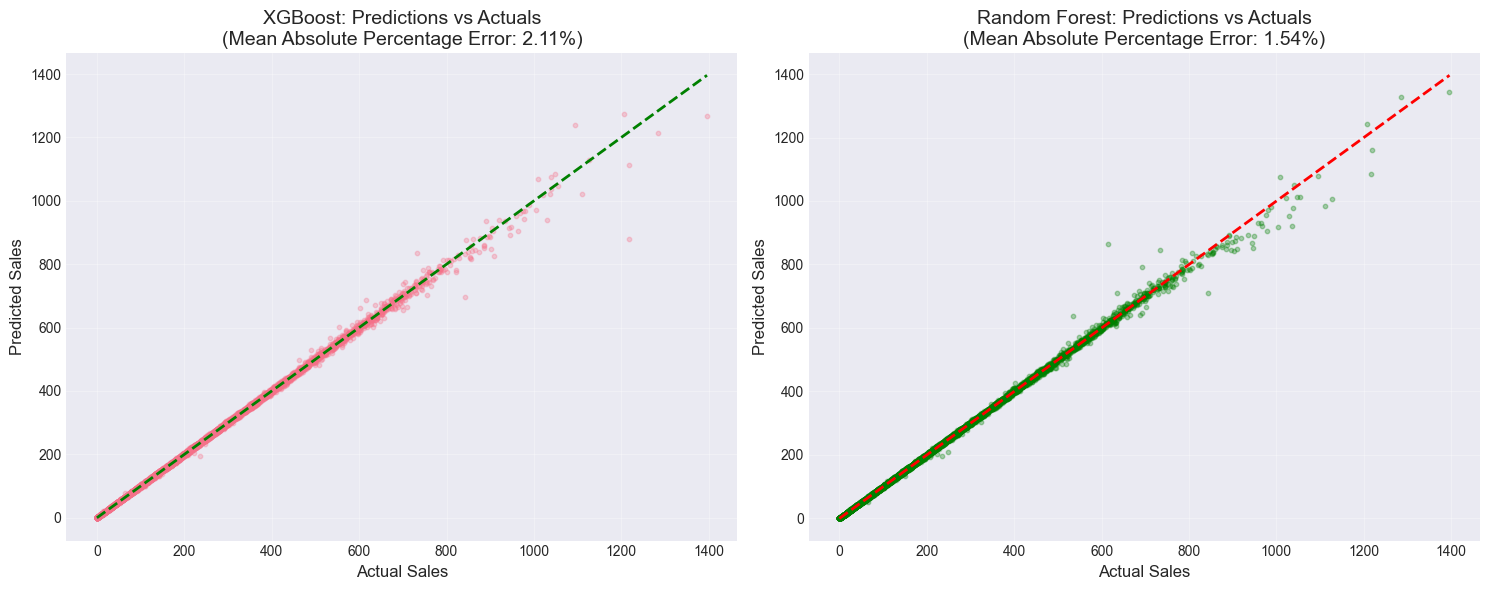

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost
axes[0].scatter(y_test, xgb_predictions, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=2)
axes[0].set_xlabel('Actual Sales', fontsize=12)
axes[0].set_ylabel('Predicted Sales', fontsize=12)
axes[0].set_title(f'XGBoost: Predictions vs Actuals\n(Mean Absolute Percentage Error: {xgb_metrics["MAPE"]}%)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, rf_predictions, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Sales', fontsize=12)
axes[1].set_ylabel('Predicted Sales', fontsize=12)
axes[1].set_title(f'Random Forest: Predictions vs Actuals\n(Mean Absolute Percentage Error: {rf_metrics["MAPE"]}%)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()